# Задача 3. Регрессия SI

**Цель:** предсказать индекс селективности SI = CC50 / IC50, отношение токсичности к активности

Среди всех трех таргетов он самый важный и одновременно самый сложный.

Важный, потому что именно SI решает, годится ли соединение в лекарство. Высокая активность ничего не стоит, если она достигается ценой токсичности
Сложный, потому что SI величина производная. Он тянет за собой шум обоих исходных измерений: асимметрия 18.0, эксцесс 361, размах от 0.011 до 15621.

Обучаем модель на log10(SI), в этом ноутбуке ,заодно, мы проверяем две гипотезы, которые подсказал EDA про композиционную модель и про влияние цензурированных измерений

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd().parent))
from src import data_utils as du  # noqa: E402
from src import modeling as mdl  # noqa: E402

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

FIG_DIR = Path.cwd().parent / "reports" / "figures"
RES_DIR = Path.cwd().parent / "results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Загрузка данных


In [2]:
features, targets, groups, clean_report = du.load_dataset()
target = targets["log_si"]

print(f"Признаков: {features.shape[1]}, объектов: {features.shape[0]}")
print(f"Уникальных молекул (групп): {len(np.unique(groups))}")
print(f"\nЦелевая переменная: log10(SI)")
print(target.describe().round(3).to_string())

Признаков: 178, объектов: 1001
Уникальных молекул (групп): 804

Целевая переменная: log10(SI)
count    1001.000
mean        0.743
std         0.754
min        -1.940
25%         0.156
50%         0.585
75%         1.219
max         4.194


## 2. Разбиение на обучение и отложенный тест


In [3]:
X_train, X_test, y_train, y_test, groups_train = mdl.group_train_test_split(
    features, target, groups
)
train_groups = set(groups[np.isin(features.index, X_train.index)])
test_groups = set(groups[np.isin(features.index, X_test.index)])

print(f"train: {X_train.shape[0]} объектов, {len(train_groups)} групп")
print(f"test:  {X_test.shape[0]} объектов, {len(test_groups)} групп")
print(f"Пересечение групп train/test: {len(train_groups & test_groups)}")

display(pd.DataFrame({
    "train": y_train.describe(),
    "test": y_test.describe(),
}).round(3))

train: 798 объектов, 643 групп
test:  203 объектов, 161 групп
Пересечение групп train/test: 0


,train,test
count,798.000,203.000
mean,0.765,0.659
std,0.755,0.744
min,-1.940,-1.076
25%,0.197,0.029
50%,0.630,0.439
75%,1.251,1.108
max,4.194,3.699


## 3. Подбор гиперпараметров и сравнение моделей

сравниваются десять моделей, которые охватывают основные классы алгоритмов,В списке константный baseline, три линейные модели с разными видами регуляризации, kNN, SVR с ядром, а также четыре ансамбля на основе деревьев 
- Качество оцениваем по R^2 на групповой кросс-валидации

In [4]:
cv_table, fitted = mdl.search_candidates(
    mdl.regression_candidates(), X_train, y_train, groups_train,
    scoring="r2", task="si_reg",
)
display(cv_table.drop(columns=["комментарий"]).round(4))

Baseline (медиана)       CV r2 = -0.0412 (±0.0295)
Ridge                    CV r2 =  0.0881 (±0.0415)
Lasso                    CV r2 =  0.0628 (±0.0548)
ElasticNet               CV r2 =  0.0717 (±0.0547)
kNN                      CV r2 =  0.1268 (±0.0782)


SVR (RBF)                CV r2 =  0.1415 (±0.0586)


Random Forest            CV r2 =  0.1857 (±0.0231)


Extra Trees              CV r2 =  0.1890 (±0.0286)


LightGBM                 CV r2 =  0.1720 (±0.0359)


XGBoost                  CV r2 =  0.1769 (±0.0423)


,модель,CV r2,std,лучшие гиперпараметры,число обучений
0,Extra Trees,0.1890,0.0286,"{'max_depth': 8, 'max_features': 0.3, 'min_sam...",150
1,Random Forest,0.1857,0.0231,"{'max_depth': 16, 'max_features': 'log2', 'min...",150
2,XGBoost,0.1769,0.0423,"{'colsample_bytree': 0.40424, 'learning_rate':...",150
3,LightGBM,0.1720,0.0359,"{'colsample_bytree': 0.67392, 'learning_rate':...",150
4,SVR (RBF),0.1415,0.0586,"{'C': 0.54152, 'epsilon': 0.16212, 'gamma': 0....",150
5,kNN,0.1268,0.0782,"{'n_neighbors': 23, 'p': 1, 'weights': 'distan...",150
6,Ridge,0.0881,0.0415,{'alpha': 904.7072},150
7,ElasticNet,0.0717,0.0547,"{'alpha': 0.09164, 'l1_ratio': 0.09181}",150
8,Lasso,0.0628,0.0548,{'alpha': 0.01907},150
9,Baseline (медиана),-0.0412,0.0295,{},5


In [5]:
display(cv_table[["модель", "комментарий", "лучшие гиперпараметры"]]
        .set_index("модель"))

,комментарий,лучшие гиперпараметры
модель,,
Extra Trees,"усиленная рандомизация разбиений, меньше диспе...","{'max_depth': 8, 'max_features': 0.3, 'min_sam..."
Random Forest,"бэггинг деревьев, устойчив к переобучению и ко...","{'max_depth': 16, 'max_features': 'log2', 'min..."
XGBoost,альтернативная реализация бустинга для перекрё...,"{'colsample_bytree': 0.40424, 'learning_rate':..."
LightGBM,"градиентный бустинг, основной кандидат на лучш...","{'colsample_bytree': 0.67392, 'learning_rate':..."
SVR (RBF),"нелинейная модель на ядре, устойчива в простра...","{'C': 0.54152, 'epsilon': 0.16212, 'gamma': 0...."
kNN,"метрическая модель, проверка локальной структу...","{'n_neighbors': 23, 'p': 1, 'weights': 'distan..."
Ridge,линейная модель с L2-регуляризацией,{'alpha': 904.7072}
ElasticNet,"компромисс L1/L2, устойчив к мультиколлинеарности","{'alpha': 0.09164, 'l1_ratio': 0.09181}"
Lasso,L1: одновременно выполняет отбор признаков,{'alpha': 0.01907}


## 4. Оценка на отложенном тесте

Модели с оптимальными гиперпараметрами дообучились на всей обучающей части и проверины на тесте, который раньше не использовался, плюсом считались две химически наглядные величины RMSE (log10), а медианная ошибка, раз

In [6]:
test_table = mdl.evaluate_on_test(fitted, X_test, y_test, task="regression")
display(test_table.round(3))
test_table.to_csv(RES_DIR / "si_reg_test_metrics.csv", index=False)

,модель,R2,RMSE (log10),MAE (log10),MedAE (исх. ед.),"медианная ошибка, раз"
0,LightGBM,0.293,0.624,0.492,2.879,2.557
1,Extra Trees,0.291,0.625,0.495,2.891,2.564
2,XGBoost,0.277,0.631,0.503,2.802,2.706
3,Random Forest,0.271,0.634,0.507,3.143,2.841
4,SVR (RBF),0.237,0.648,0.497,2.787,2.408
5,kNN,0.235,0.649,0.528,3.971,2.792
6,ElasticNet,0.111,0.700,0.550,3.520,3.084
7,Ridge,0.107,0.701,0.560,3.604,3.286
8,Lasso,0.099,0.704,0.560,3.704,3.060
9,Baseline (медиана),-0.001,0.742,0.589,3.270,3.751


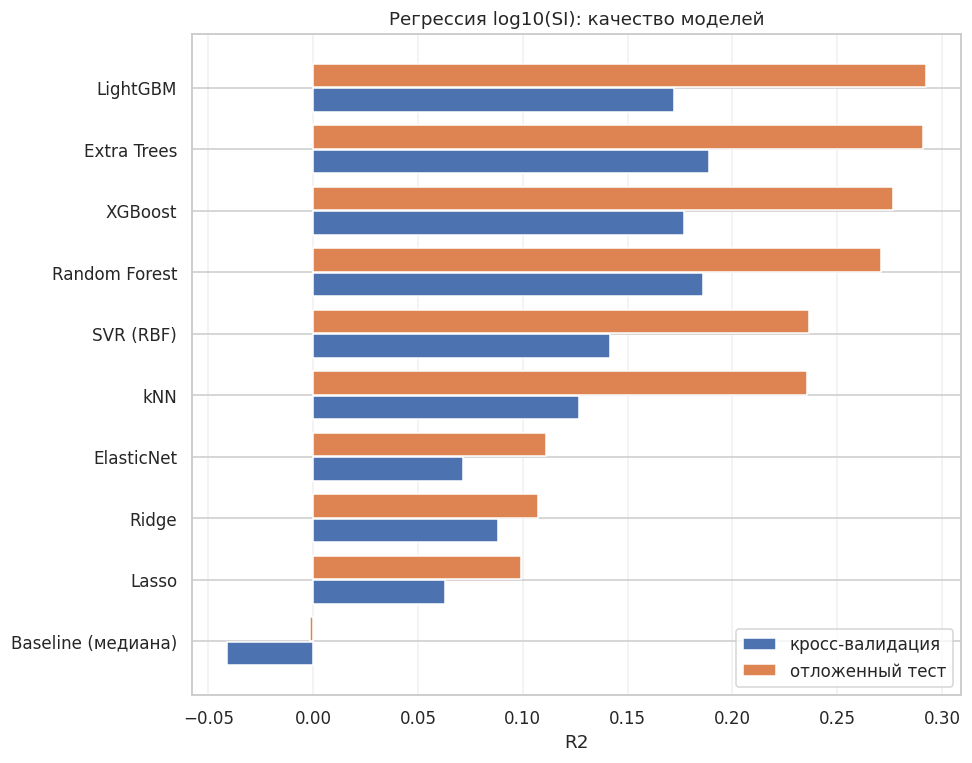

In [7]:
mdl.plot_cv_vs_test(
    cv_table, test_table, "CV r2", "R2",
    "Регрессия log10(SI): качество моделей",
    save_path=FIG_DIR / "si_reg_models_comparison.png",
)

## 5. Диагностика лучшей модели

Три графика отвечают на разные вопросы: есть ли систематическое смещение прогноза,
однородна ли ошибка по диапазону значений, нормальны ли остатки.

Лучшая модель на тесте: LightGBM


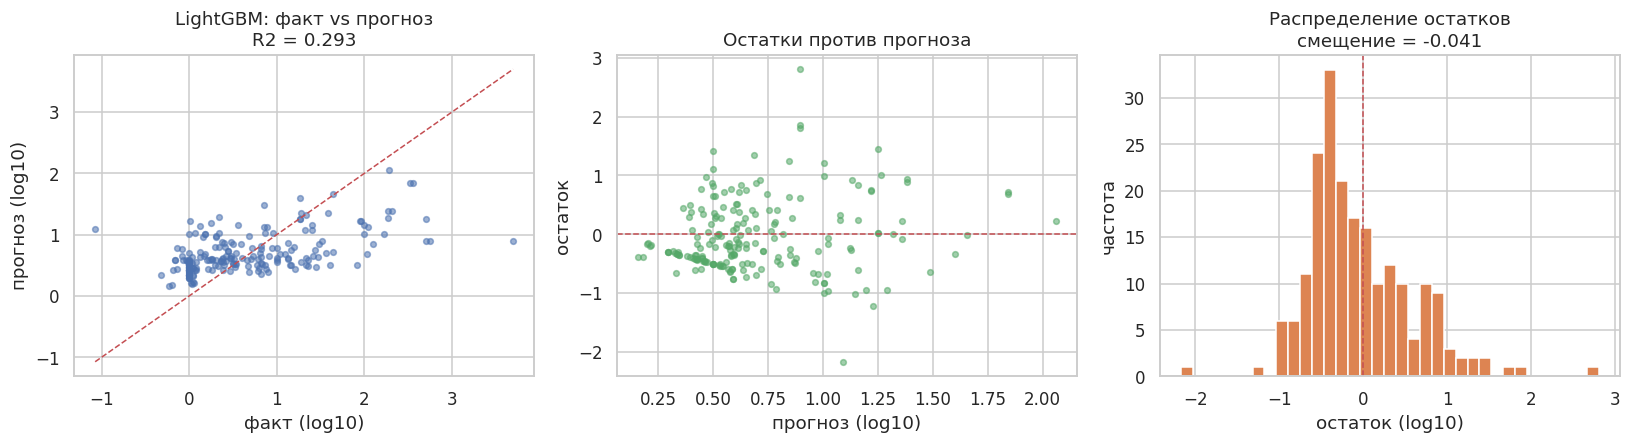

In [8]:
best_name = test_table.iloc[0]["модель"]
best_model = fitted[best_name]
print(f"Лучшая модель на тесте: {best_name}")

predictions = best_model.predict(X_test)
mdl.plot_regression_diagnostics(
    y_test.to_numpy(), predictions, best_name,
    save_path=FIG_DIR / "si_reg_diagnostics.png",
)

In [9]:
errors = pd.DataFrame({
    "факт": y_test.to_numpy(),
    "прогноз": predictions,
    "остаток": y_test.to_numpy() - predictions,
})
quartiles = pd.qcut(errors["факт"], 4,
                    labels=["Q1 (низкие)", "Q2", "Q3", "Q4 (высокие)"])
print("Средний остаток и MAE по квартилям истинного значения:")
display(errors.groupby(quartiles)["остаток"].agg(
    смещение="mean", MAE=lambda s: s.abs().mean(), объектов="size").round(3))

Средний остаток и MAE по квартилям истинного значения:


,смещение,MAE,объектов
факт,,,
Q1 (низкие),-0.551,0.551,51
Q2,-0.421,0.421,51
Q3,0.064,0.229,50
Q4 (высокие),0.744,0.760,51


## 6. дескрипторы определяющие прогноз

Используется permutation importance на отложенном тесте: признак перемешивается и измеряеться падение R^2

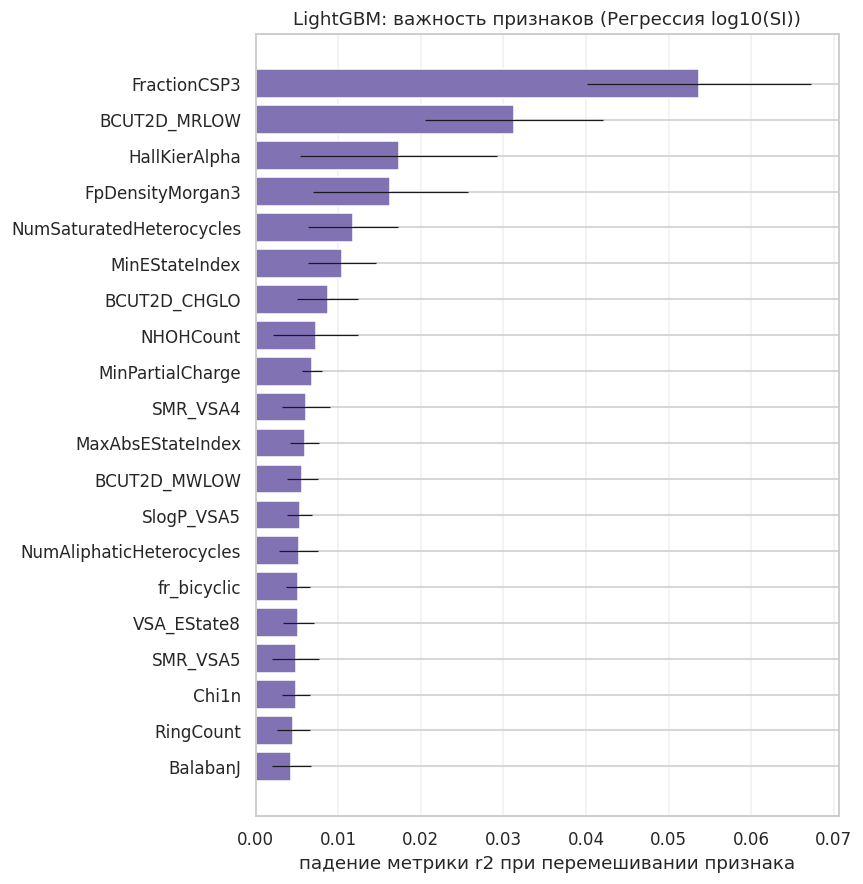

,признак,падение качества,std
0,FractionCSP3,0.0537,0.0136
1,BCUT2D_MRLOW,0.0313,0.0108
2,HallKierAlpha,0.0173,0.0119
3,FpDensityMorgan3,0.0163,0.0094
4,NumSaturatedHeterocycles,0.0118,0.0055
5,MinEStateIndex,0.0105,0.0041
6,BCUT2D_CHGLO,0.0087,0.0037
7,NHOHCount,0.0073,0.0051
8,MinPartialCharge,0.0069,0.0012
9,SMR_VSA4,0.0061,0.0030


In [10]:
importance = mdl.plot_permutation_importance(
    best_model, X_test, y_test, scoring="r2",
    title=f"{best_name}: важность признаков (Регрессия log10(SI))",
    save_path=FIG_DIR / "si_reg_importance.png",
)
display(importance.head(15).round(4))
importance.to_csv(RES_DIR / "si_reg_importance.csv", index=False)

## 7. Устойчивость результата

Одно разбиение train/test даёт лишь точечную оценку. Повторяем обучение и измерение на пяти независимых групповых разбиениях, чтобы понять, насколько приведённые цифры воспроизводимы

In [11]:
from sklearn.metrics import r2_score

stability = mdl.stability_check(
    best_model, features, target, groups,
    scoring=lambda y_true, model, X: r2_score(y_true, model.predict(X)),
)
display(stability.round(4))

Среднее = 0.1540, std = 0.1071, размах = 0.2553


,seed,метрика
0,0,-0.0126
1,1,0.2197
2,2,0.2144
3,3,0.1059
4,4,0.2427


## 8. Эксперимент 1: композиционная модель вместо прямой

В EDA установлено, что SI = CC50 / IC50 выполняется точно, а значит

$$\log_{10} SI = \log_{10} CC50 - \log_{10} IC50.$$

обучить две модели — для log CC50 и log IC50 — и вычитать их предсказания, получая SI. Плючы , каждая задача чище , минусы ошибки суммируются. Разбиение данных у всех трёх таргетов одно и то же, так что сравнение корректно

In [12]:
from sklearn.base import clone
from sklearn.metrics import r2_score

component_predictions = {}
for name, column, task_name in [
    ("IC50", "log_ic50", "ic50_reg"),
    ("CC50", "log_cc50", "cc50_reg"),
]:
    X_tr, X_te, y_tr, y_te, g_tr = mdl.group_train_test_split(
        features, targets[column], groups
    )
    _, component_models = mdl.search_candidates(
        [c for c in mdl.regression_candidates() if c.name == best_name],
        X_tr, y_tr, g_tr, scoring="r2", task=task_name, verbose=False,
    )
    component_predictions[name] = component_models[best_name].predict(X_te)
    print(f"Модель {name}: R2 на тесте = "
          f"{r2_score(y_te, component_predictions[name]):.3f}")

composed = component_predictions["CC50"] - component_predictions["IC50"]

Модель IC50: R2 на тесте = 0.501


Модель CC50: R2 на тесте = 0.576


,R2,RMSE (log10),MAE (log10),MedAE (исх. ед.),"медианная ошибка, раз"
подход,,,,,
прямая регрессия log SI,0.293,0.624,0.492,2.879,2.557
композиция: log CC50 − log IC50,0.259,0.638,0.493,3.120,2.576


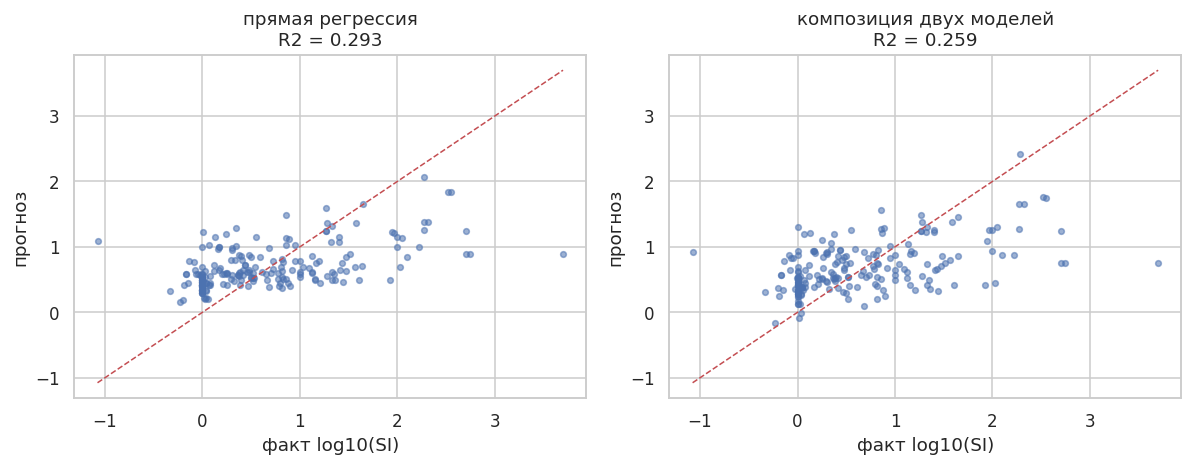

In [13]:
comparison = pd.DataFrame([
    {"подход": "прямая регрессия log SI",
     **mdl.regression_metrics(y_test.to_numpy(), predictions)},
    {"подход": "композиция: log CC50 − log IC50",
     **mdl.regression_metrics(y_test.to_numpy(), composed)},
]).set_index("подход")
display(comparison.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
lims = [y_test.min(), y_test.max()]
for ax, pred, label in [
    (axes[0], predictions, "прямая регрессия"),
    (axes[1], composed, "композиция двух моделей"),
]:
    ax.scatter(y_test, pred, s=14, alpha=.55)
    ax.plot(lims, lims, "r--", lw=1)
    ax.set(xlabel="факт log10(SI)", ylabel="прогноз",
           title=f"{label}\nR2 = {r2_score(y_test, pred):.3f}")
plt.tight_layout()
plt.savefig(FIG_DIR / "si_reg_composition.png", dpi=140, bbox_inches="tight")
plt.show()

**Вывод по эксперименту 1.** Композиция не выигрывает у прямой регрессии: ошибки двух моделей суммируются. Лучше учить log SI напрямую

## 9. Эксперимент 2: влияние цензурированных измерений
У 135 объектов SI = 1 из-за цензурирования, неактивные соединения помечены граничной концентрацией. бесперспективны, истинный SI неизвестен
- Проверим, насколько эти объекты ограничивают качество регрессии.

In [14]:
censored = (targets["si"] - 1.0).abs() < 1e-9
print(f"Цензурированных объектов: {censored.sum()} ({censored.mean():.1%})")

X_clean = features[~censored.to_numpy()]
y_clean = targets.loc[~censored, "log_si"]
g_clean = groups[~censored.to_numpy()]

Xc_tr, Xc_te, yc_tr, yc_te, gc_tr = mdl.group_train_test_split(
    X_clean, y_clean, g_clean
)
clean_cv, clean_fitted = mdl.search_candidates(
    mdl.regression_candidates(), Xc_tr, yc_tr, gc_tr,
    scoring="r2", task="si_reg_nocensored", verbose=False,
)
clean_test = mdl.evaluate_on_test(clean_fitted, Xc_te, yc_te, task="regression")
display(clean_test.round(3))

Цензурированных объектов: 135 (13.5%)


,модель,R2,RMSE (log10),MAE (log10),MedAE (исх. ед.),"медианная ошибка, раз"
0,LightGBM,0.296,0.599,0.447,4.579,2.171
1,Extra Trees,0.272,0.609,0.462,4.613,2.392
2,XGBoost,0.271,0.609,0.467,4.479,2.308
3,Random Forest,0.260,0.614,0.468,4.438,2.328
4,SVR (RBF),0.241,0.622,0.465,4.641,2.328
5,kNN,0.237,0.623,0.480,5.185,2.510
6,ElasticNet,0.187,0.643,0.496,4.708,2.396
7,Lasso,0.186,0.644,0.499,4.813,2.439
8,Ridge,0.185,0.644,0.493,4.768,2.368
9,Baseline (медиана),-0.056,0.733,0.572,4.283,3.030


In [15]:
summary = pd.DataFrame({
    "с цензурированными (n=1001)": {
        "лучший CV R2": cv_table["CV r2"].max(),
        "лучший тест R2": test_table["R2"].max(),
        "разброс таргета (std)": targets["log_si"].std(),
    },
    "без цензурированных (n=%d)" % (~censored).sum(): {
        "лучший CV R2": clean_cv["CV r2"].max(),
        "лучший тест R2": clean_test["R2"].max(),
        "разброс таргета (std)": y_clean.std(),
    },
})
display(summary.round(3))

,с цензурированными (n=1001),без цензурированных (n=866)
лучший CV R2,0.189,0.170
лучший тест R2,0.293,0.296
разброс таргета (std),0.754,0.746


**Вывод по эксперименту 2** Удаление цензурированных объектов не помогли ,но они и так предсказываются отлично поэтому отсавляем , отмечает активы от негативов и оценивает СИ среди активов , задача SI двойная поэтому классификация дает больше пользы чем регрессия 

## 10. Выводы по задаче регрессии SI
основная модлеь Extra Trees на log10(SI). Композицию оставляем как сторожевой механизм, если две модели расходятся, молекула нетипична для данных

